## Building Permits Data Analysis

In [1]:
#import libiaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df=pd.read_csv("Building_Permits.csv",low_memory=False)
df.head()

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,...,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID
0,201505065519,4,sign - erect,05/06/2015,0326,023,140,NaN,Ellis,St,...,3.0,constr type 3,NaN,NaN,NaN,3.0,Tenderloin,94102.0,"(37.785719256680785, -122.40852313194863)",1380611233945
1,201604195146,4,sign - erect,04/19/2016,0306,007,440,NaN,Geary,St,...,3.0,constr type 3,NaN,NaN,NaN,3.0,Tenderloin,94102.0,"(37.78733980600732, -122.41063199757738)",1420164406718
2,201605278609,3,additions alterations or repairs,05/27/2016,0595,203,1647,NaN,Pacific,Av,...,1.0,constr type 1,1.0,constr type 1,NaN,3.0,Russian Hill,94109.0,"(37.7946573324287, -122.42232562979227)",1424856504716
3,201611072166,8,otc alterations permit,11/07/2016,0156,011,1230,NaN,Pacific,Av,...,5.0,wood frame (5),5.0,wood frame (5),NaN,3.0,Nob Hill,94109.0,"(37.79595867909168, -122.41557405519474)",1443574295566
4,201611283529,6,demolitions,11/28/2016,0342,001,950,NaN,Market,St,...,3.0,constr type 3,NaN,NaN,NaN,6.0,Tenderloin,94102.0,"(37.78315261897309, -122.40950883997789)",144548169992


In [3]:
#finding missing value %
missing_percent=(df.isnull().sum()/len(df))*100
missing_percent.sort_values(ascending=False)

TIDF Compliance                           99.998994
Voluntary Soft-Story Retrofit             99.982403
Unit Suffix                               99.014077
Street Number Suffix                      98.885872
Site Permit                               97.305681
Structural Notification                   96.519859
Fire Only Permit                          90.534439
Unit                                      85.178984
Completed Date                            51.135747
Permit Expiration Date                    26.083459
Existing Units                            25.911513
Proposed Units                            25.596280
Existing Construction Type Description    21.802916
Existing Construction Type                21.802916
Proposed Construction Type                21.700352
Proposed Construction Type Description    21.700352
Number of Proposed Stories                21.552539
Number of Existing Stories                21.510307
Proposed Use                              21.336853
Existing Use

In [4]:
#drop the most missing % columns
cols_to_drop=missing_percent[missing_percent>60].index
df1=df.drop(columns=cols_to_drop).copy()
df1

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Name,Street Suffix,Description,...,Plansets,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID
0,201505065519,4,sign - erect,05/06/2015,0326,023,140,Ellis,St,"ground fl facade: to erect illuminated, electr...",...,2.0,3.0,constr type 3,NaN,NaN,3.0,Tenderloin,94102.0,"(37.785719256680785, -122.40852313194863)",1380611233945
1,201604195146,4,sign - erect,04/19/2016,0306,007,440,Geary,St,remove (e) awning and associated signs.,...,2.0,3.0,constr type 3,NaN,NaN,3.0,Tenderloin,94102.0,"(37.78733980600732, -122.41063199757738)",1420164406718
2,201605278609,3,additions alterations or repairs,05/27/2016,0595,203,1647,Pacific,Av,installation of separating wall,...,2.0,1.0,constr type 1,1.0,constr type 1,3.0,Russian Hill,94109.0,"(37.7946573324287, -122.42232562979227)",1424856504716
3,201611072166,8,otc alterations permit,11/07/2016,0156,011,1230,Pacific,Av,repair dryrot & stucco at front of bldg.,...,2.0,5.0,wood frame (5),5.0,wood frame (5),3.0,Nob Hill,94109.0,"(37.79595867909168, -122.41557405519474)",1443574295566
4,201611283529,6,demolitions,11/28/2016,0342,001,950,Market,St,demolish retail/office/commercial 3-story buil...,...,2.0,3.0,constr type 3,NaN,NaN,6.0,Tenderloin,94102.0,"(37.78315261897309, -122.40950883997789)",144548169992
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198895,M862628,8,otc alterations permit,12/05/2017,0113,017A,1228,Montgomery,St,street space,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1489337276729
198896,201712055595,8,otc alterations permit,12/05/2017,0271,014,580,Bush,St,fire alarm upgrade ref 201704123852,...,2.0,5.0,wood frame (5),5.0,wood frame (5),NaN,NaN,NaN,NaN,1489462354993
198897,M863507,8,otc alterations permit,12/06/2017,4318,019,1568,Indiana,St,street space,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1489539379952
198898,M863747,8,otc alterations permit,12/06/2017,0298,029,795,Sutter,St,street space permit,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1489608233656


In [5]:
df1.dtypes

Permit Number                              object
Permit Type                                 int64
Permit Type Definition                     object
Permit Creation Date                       object
Block                                      object
Lot                                        object
Street Number                               int64
Street Name                                object
Street Suffix                              object
Description                                object
Current Status                             object
Current Status Date                        object
Filed Date                                 object
Issued Date                                object
Completed Date                             object
First Construction Document Date           object
Number of Existing Stories                float64
Number of Proposed Stories                float64
Permit Expiration Date                     object
Estimated Cost                            float64


In [6]:
#filling with unknown for text columns
category_cols=df1.select_dtypes(include=["object"]).columns
cat_cols_to_fill=[col for col in category_cols
                  if col not in ["Issued Date","Filed Date"]]
df1[cat_cols_to_fill]=df1[cat_cols_to_fill].fillna("unknown")

In [7]:
#filling with median for numeric column(Estimated Cost)
median_cost=df1["Estimated Cost"].median()
if "Estimated Cost" in df1.columns:
    df1["Estimated Cost"]=df1["Estimated Cost"].fillna(median_cost)

In [8]:
#drop row with nan
df2=df1.dropna(subset=["Issued Date"]).copy()

In [9]:
print(f"Original Shape: {df.shape}")
print(f"Cleaned Shape: {df2.shape}")

Original Shape: (198900, 43)
Cleaned Shape: (183960, 35)


In [10]:
#formatting date columns
df2["Issued Date"]=pd.to_datetime(df2["Issued Date"],format="%m/%d/%Y")
df2["Filed Date"]=pd.to_datetime(df2["Filed Date"],format="%m/%d/%Y")

## EDA(Exploratory Data Analysis)

### Adding required columns for Data Analysis

In [11]:
#adding issue duration days column
df2["Issue_duration_days"]=(df2["Issued Date"]-df2["Filed Date"]).dt.days

In [12]:
#adding filed day column
df2["Filed_day"]=df2["Filed Date"].dt.day_name()

In [13]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df2['Filed_day'] = pd.Categorical(df2['Filed_day'], categories=days_order, ordered=True)

In [14]:
#checking
df2[["Filed Date","Issued Date","Issue_duration_days","Filed_day"]].head()

,Filed Date,Issued Date,Issue_duration_days,Filed_day
0,2015-05-06,2015-11-09,187,Wednesday
1,2016-04-19,2017-08-03,471,Tuesday
3,2016-11-07,2017-07-18,253,Monday
4,2016-11-28,2017-12-01,368,Monday
5,2017-06-14,2017-07-06,22,Wednesday


### Calculating summary statistics 

In [15]:
#getting permit duration day 
valid_permits=df2[df2["Issue_duration_days"]>=0].copy()

In [16]:
#summary statistics
print("=====Issue Duration Overall Summary (Days)=====")
print(f"Mean: {valid_permits["Issue_duration_days"].mean():.2f} Days")
print(f"Median: {valid_permits["Issue_duration_days"].median():.2f} Days")
print(f"Max: {valid_permits["Issue_duration_days"].max():.2f} Days")

=====Issue Duration Overall Summary (Days)=====
Mean: 26.05 Days
Median: 0.00 Days
Max: 1740.00 Days


### 1. Calculating median Duration by Permit Type

In [17]:
duration_by_type=valid_permits.groupby("Permit Type Definition")["Issue_duration_days"].agg([
    "count","mean","median"]).reset_index().sort_values(by='median', ascending=False)
duration_by_type

,Permit Type Definition,count,mean,median
3,new construction,176,478.602273,419.5
4,new construction wood frame,601,398.143095,303.0
1,demolitions,377,348.175066,218.0
0,additions alterations or repairs,9439,247.252251,203.0
2,grade or quarry or fill or excavate,78,97.307692,68.5
6,sign - erect,2403,52.724511,10.0
7,wall or painted sign,362,45.348066,9.0
5,otc alterations permit,170524,10.870757,0.0


### 2. On which days of the week are the highest number of permit applications filed?

In [18]:
daily_applications=df2["Filed_day"].value_counts().sort_index().sort_values(ascending=False)
daily_applications

Filed_day
Tuesday      39765
Thursday     37612
Wednesday    36874
Friday       36760
Monday       32949
Saturday         0
Sunday           0
Name: count, dtype: int64

In [19]:
#Median Issue Duration vs Day Filed
daily_duration=valid_permits.groupby("Filed_day",observed=False)["Issue_duration_days"].median()
daily_duration

Filed_day
Monday       0.0
Tuesday      0.0
Wednesday    0.0
Thursday     0.0
Friday       0.0
Saturday     NaN
Sunday       NaN
Name: Issue_duration_days, dtype: float64

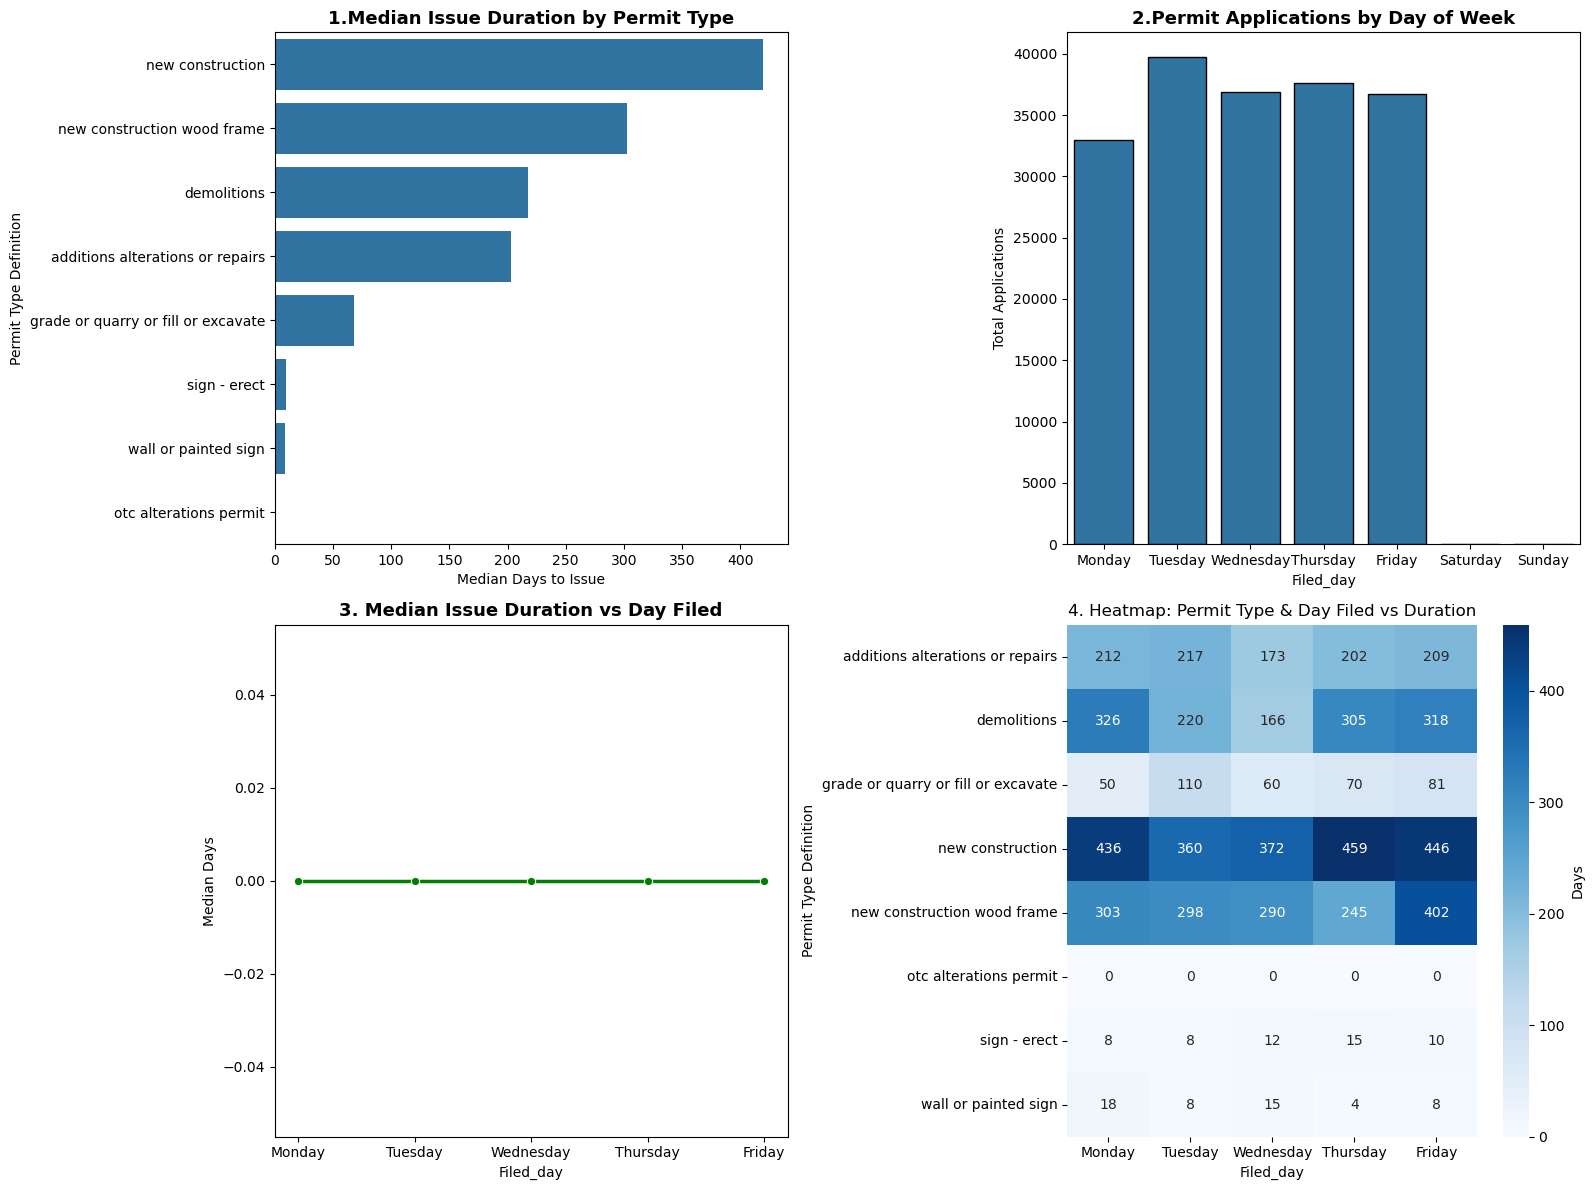

In [28]:
#plotting
fig,axes=plt.subplots(2,2,figsize=(16,12))

#Median Duration by Permit Type
sns.barplot(data=duration_by_type,x="median",y="Permit Type Definition",ax=axes[0,0])
axes[0,0].set_title("1.Median Issue Duration by Permit Type", fontsize=13,fontweight="bold")
axes[0,0].set_xlabel("Median Days to Issue")

#Applications by Day of Week
sns.barplot(x=daily_applications.index,y=daily_applications.values,ax=axes[0,1],edgecolor="black")
axes[0,1].set_title("2.Permit Applications by Day of Week", fontsize=13,fontweight="bold")
axes[0,1].set_ylabel('Total Applications')

#Median Issue Duration vs Day Filed
sns.lineplot(x=daily_duration.index, y=daily_duration.values,marker="o",ax=axes[1,0],linewidth=2.5,color="green")
axes[1,0].set_title("3. Median Issue Duration vs Day Filed", fontsize=13,fontweight="bold")
axes[1,0].set_ylabel('Median Days')

#Heatmap (Permit Type vs Day Filed - Median Duration)

pivot_df = valid_permits.pivot_table(
    index="Permit Type Definition",
    columns="Filed_day",
    values="Issue_duration_days",
    aggfunc="median",
    observed=False
)
sns.heatmap(pivot_df, annot=True, fmt=".0f",ax=axes[1, 1], cmap="Blues",cbar_kws={"label": "Days"})
plt.title("4. Heatmap: Permit Type & Day Filed vs Duration")



plt.tight_layout()
plt.show()